In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ammarridho/drowsiness-cut")

print("Path to dataset files:", path)

100%|██████████| 5.28G/5.28G [00:52<00:00, 107MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ammarridho/drowsiness-cut/versions/1


In [2]:
import os
import cv2
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization,
    LSTM, TimeDistributed
)
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split


In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D,
    Dense, Dropout, Flatten,
    BatchNormalization
)

def build_cnn_model():
    model = Sequential()

    # Block 1
    model.add(Conv2D(32, (3,3), activation='relu',
                     input_shape=(100, 100, 3)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2,2))

    # Block 2
    model.add(Conv2D(64, (3,3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2,2))

    # Block 3
    model.add(Conv2D(128, (3,3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2,2))

    # Block 4
    model.add(Conv2D(256, (3,3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2,2))

    # Classification head
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))

    return model


In [4]:
model = build_cnn_model()

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 98, 98, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 47, 47, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 21, 21, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 914,881 (3.49 MB)

 Trainable params: 913,921 (3.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (100, 100)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)


train_gen = datagen.flow_from_directory(
    path + "/dataset",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    path + "/dataset",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False
)


Found 12413 images belonging to 2 classes.
Found 3103 images belonging to 2 classes.


In [6]:
print(train_gen.class_indices)


{'drowsiness': 0, 'non-drowsiness': 1}


In [7]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)


In [8]:
EPOCHS = 20

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[early_stop]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 189s 465ms/step - accuracy: 0.5736 - loss: 0.8894 - val_accuracy: 0.4808 - val_loss: 2.7312
Epoch 2/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 143s 369ms/step - accuracy: 0.6983 - loss: 0.5540 - val_accuracy: 0.6001 - val_loss: 0.6748
Epoch 3/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 144s 371ms/step - accuracy: 0.7969 - loss: 0.4191 - val_accuracy: 0.5682 - val_loss: 0.6876
Epoch 4/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 145s 373ms/step - accuracy: 0.8717 - loss: 0.2947 - val_accuracy: 0.6777 - val_loss: 0.6592
Epoch 5/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 146s 375ms/step - accuracy: 0.9106 - loss: 0.2126 - val_accuracy: 0.5553 - val_loss: 1.1185
Epoch 6/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 143s 367ms/step - accuracy: 0.9273 - loss: 0.1855 - val_accuracy: 0.5856 - val_loss: 1.3006
Epoch 7/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 145s 374ms/step - accuracy: 0.9588 - loss: 0.1123 - val_accuracy: 0.5160 - val_loss: 2.1038
Epoch 8/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 145s 374ms/step - accuracy: 0.9536 -

In [9]:
import numpy as np

# Get true labels
y_true = val_gen.classes

# Predict probabilities
y_pred_prob = model.predict(val_gen)

# Convert probabilities → class labels (0 or 1)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()


97/97 ━━━━━━━━━━━━━━━━━━━━ 28s 279ms/step


In [10]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)


[[ 878  614]
 [ 448 1163]]


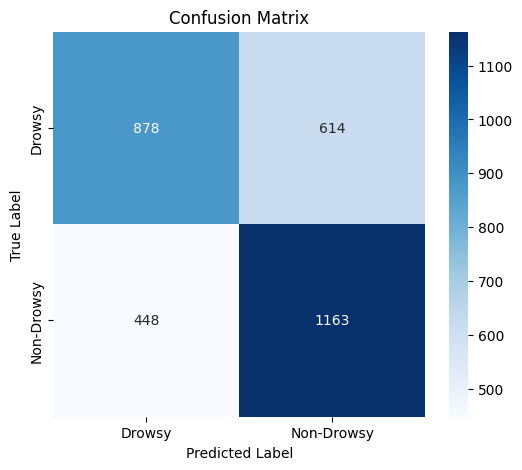

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Drowsy", "Non-Drowsy"],
    yticklabels=["Drowsy", "Non-Drowsy"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [12]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=["Drowsy", "Non-Drowsy"]
))


              precision    recall  f1-score   support

      Drowsy       0.66      0.59      0.62      1492
  Non-Drowsy       0.65      0.72      0.69      1611

    accuracy                           0.66      3103
   macro avg       0.66      0.66      0.65      3103
weighted avg       0.66      0.66      0.66      3103



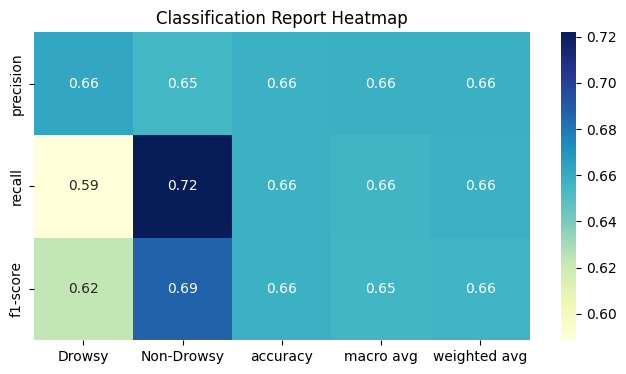

In [13]:
import pandas as pd

report = classification_report(
    y_true,
    y_pred,
    target_names=["Drowsy", "Non-Drowsy"],
    output_dict=True
)

df_report = pd.DataFrame(report).iloc[:-1, :]  # remove accuracy row

plt.figure(figsize=(8,4))
sns.heatmap(df_report, annot=True, cmap="YlGnBu")
plt.title("Classification Report Heatmap")
plt.show()


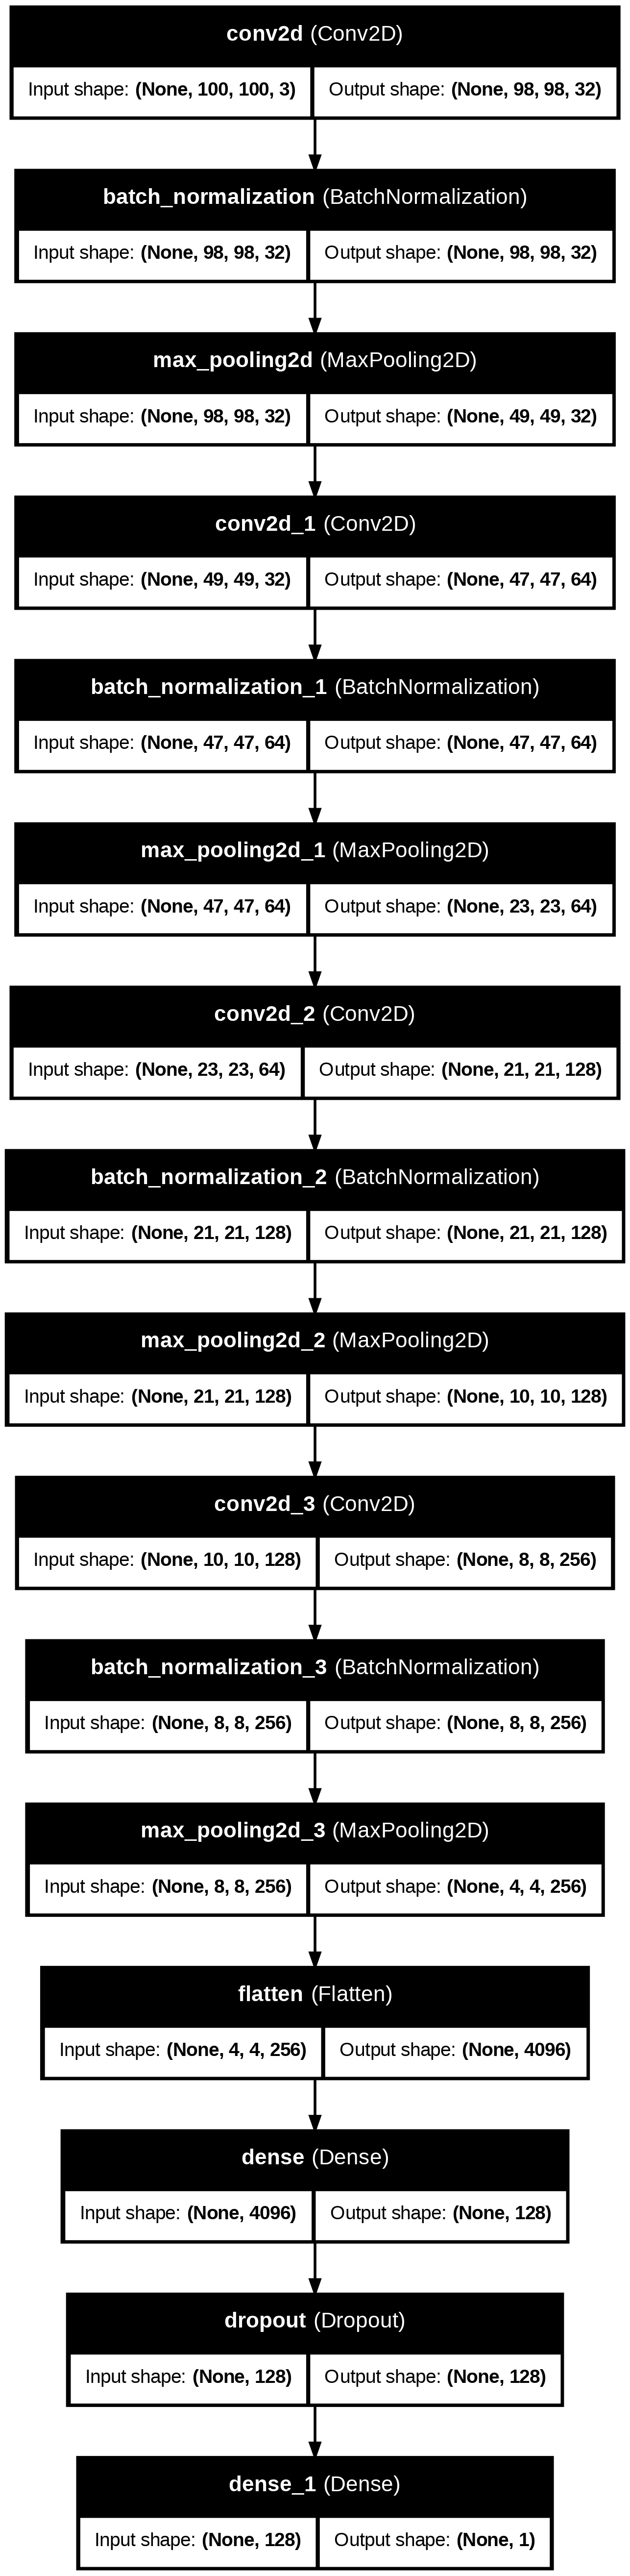

In [16]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    show_shapes=True,
    show_layer_names=True,
    to_file="cnn_architecture.png"
)


In [17]:
model.save("cnn_drowsiness_stage1.h5")
print("CNN model saved with best weights")


CNN model saved with best weights
